# Decision Tree C5.0 With ROS



## preparation

In [1]:
from google.colab import drive
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn import preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import ast
from collections import Counter
import numpy as np
import math
import joblib
from numpy import mean
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import time
import resource


## load data

In [2]:
drive.mount('/content/drive')
# data =pd.read_csv('/content/drive/MyDrive/DRAFIX/DATA/PREPROCESSING/preprofix.csv', delimiter=";")
## Membaca file Excel dari Google Drive dan menyimpannya ke dalam DataFrame
data = pd.read_csv("https://raw.githubusercontent.com/08-Ahlaqul-Karimah/Pariwisata-New/main/preprofix.csv", delimiter=";" )
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,lokasi,Sentimen,komentar,clean,tokenize,normalize,stopword,stemming
0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '..."
1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'air', 'terjun', 'diata...","['tempat', 'bagus', 'air', 'terjun', 'atas', '..."
2,Air terjun toroan,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus']
3,Air terjun toroan,Positif,Mantap,Mantap,['mantap'],['mantap'],['mantap'],['mantap']
4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"['pemandangan', 'yg', 'indah', 'adem', 'pula',...","['pemandangan', 'yang', 'indah', 'adem', 'pula...","['pemandangan', 'indah', 'adem', 'suasanyanya'...","['pandang', 'indah', 'adem', 'suasanyanya', 'p..."


In [3]:
data = data.rename(columns={'tokenize': 'tokenize dan case folding'})

In [4]:
data

,lokasi,Sentimen,komentar,clean,tokenize dan case folding,normalize,stopword,stemming
0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '..."
1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'air', 'terjun', 'diata...","['tempat', 'bagus', 'air', 'terjun', 'atas', '..."
2,Air terjun toroan,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus']
3,Air terjun toroan,Positif,Mantap,Mantap,['mantap'],['mantap'],['mantap'],['mantap']
4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"['pemandangan', 'yg', 'indah', 'adem', 'pula',...","['pemandangan', 'yang', 'indah', 'adem', 'pula...","['pemandangan', 'indah', 'adem', 'suasanyanya'...","['pandang', 'indah', 'adem', 'suasanyanya', 'p..."
...,...,...,...,...,...,...,...,...
5643,toron simalem,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus']
5644,toron simalem,Positif,Siiiip,Siiiip,['siiiip'],['siiiip'],['siiiip'],['siiiip']
5645,toron simalem,Positif,serru,serru,['serru'],['serru'],['serru'],['serru']
5646,toron simalem,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus']


## preprocessing

In [5]:
# Fungsi untuk mengubah string list ke list of words
def convert_text_list(texts):
    try:
        texts = ast.literal_eval(texts)
        return texts
    except (SyntaxError, ValueError):
        return []

# Menerapkan fungsi convert_text_list pada kolom 'stemming'
data["stemming_list"] = data["stemming"].apply(convert_text_list)

# # Memastikan 'stemming_list' adalah list of words
# print("Data Stemming List:")
# print(data[["stemming_list"]])

# Fungsi untuk menghitung term frequency (TF) dari list of words
def compute_tf(text_list):
    term_count = Counter(text_list)
    total_terms = len(text_list)
    tf_dict = {term: count / total_terms for term, count in term_count.items()}
    return tf_dict

In [6]:
data["stemming_list"] = data["stemming"].apply(convert_text_list)
data

,lokasi,Sentimen,komentar,clean,tokenize dan case folding,normalize,stopword,stemming,stemming_list
0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'air', 'terjun', 'diata...","['tempat', 'bagus', 'air', 'terjun', 'atas', '...","[tempat, bagus, air, terjun, atas, rest, area,..."
2,Air terjun toroan,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]
3,Air terjun toroan,Positif,Mantap,Mantap,['mantap'],['mantap'],['mantap'],['mantap'],[mantap]
4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"['pemandangan', 'yg', 'indah', 'adem', 'pula',...","['pemandangan', 'yang', 'indah', 'adem', 'pula...","['pemandangan', 'indah', 'adem', 'suasanyanya'...","['pandang', 'indah', 'adem', 'suasanyanya', 'p...","[pandang, indah, adem, suasanyanya, pinggir, l..."
...,...,...,...,...,...,...,...,...,...
5643,toron simalem,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]
5644,toron simalem,Positif,Siiiip,Siiiip,['siiiip'],['siiiip'],['siiiip'],['siiiip'],[siiiip]
5645,toron simalem,Positif,serru,serru,['serru'],['serru'],['serru'],['serru'],[serru]
5646,toron simalem,Positif,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]


## Random Oversampling

Sentimen
Positif    4209
Negatif    1049
Netral      390
Name: count, dtype: int64


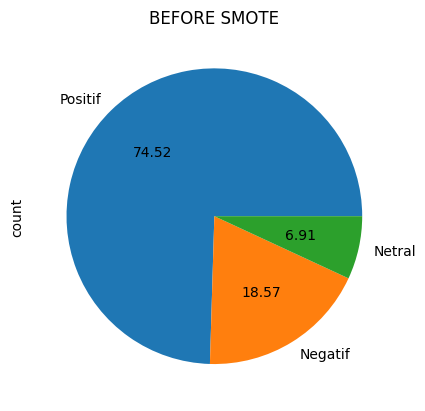

In [7]:
# split data
y = data['Sentimen']
print(pd.Series(y).value_counts())
ay = y.value_counts().plot.pie(autopct = '%.2f')
grafik = ay.set_title("BEFORE SMOTE")

In [8]:
data[["komentar",	"clean",	"tokenize dan case folding",	"normalize",	"stopword",	"stemming",	"stemming_list"]]

,komentar,clean,tokenize dan case folding,normalize,stopword,stemming,stemming_list
0,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'air', 'terjun', 'diata...","['tempat', 'bagus', 'air', 'terjun', 'atas', '...","[tempat, bagus, air, terjun, atas, rest, area,..."
2,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]
3,Mantap,Mantap,['mantap'],['mantap'],['mantap'],['mantap'],[mantap]
4,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"['pemandangan', 'yg', 'indah', 'adem', 'pula',...","['pemandangan', 'yang', 'indah', 'adem', 'pula...","['pemandangan', 'indah', 'adem', 'suasanyanya'...","['pandang', 'indah', 'adem', 'suasanyanya', 'p...","[pandang, indah, adem, suasanyanya, pinggir, l..."
...,...,...,...,...,...,...,...
5643,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]
5644,Siiiip,Siiiip,['siiiip'],['siiiip'],['siiiip'],['siiiip'],[siiiip]
5645,serru,serru,['serru'],['serru'],['serru'],['serru'],[serru]
5646,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]


Sentimen
Positif    4209
Negatif    4209
Netral     4209
Name: count, dtype: int64


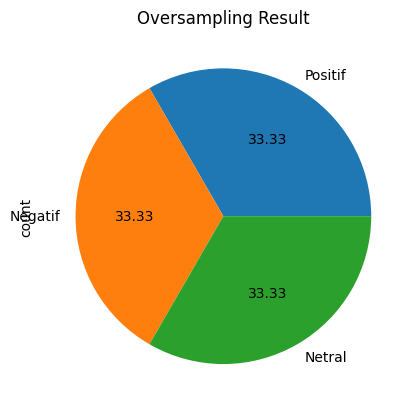

In [9]:
# Melakukan random oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(data[["komentar",	"clean",	"tokenize dan case folding",	"normalize",	"stopword",	"stemming",	"stemming_list"]], y)

# Menampilkan distribusi kelas setelah oversampling
print(pd.Series(y_resampled).value_counts())

ax = y_resampled.value_counts().plot.pie(autopct='%.2f')
grafik = ax.set_title("Oversampling Result")

In [10]:
y_resampled.loc[1073]

'Positif'

In [11]:
X_resampled

,komentar,clean,tokenize dan case folding,normalize,stopword,stemming,stemming_list
0,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'yang', 'bagus', 'tiket', 'm...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","['air', 'terjun', 'bagus', 'tiket', 'masuk', '...","[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'selain', 'air', 'terju...","['tempatnya', 'bagus', 'air', 'terjun', 'diata...","['tempat', 'bagus', 'air', 'terjun', 'atas', '...","[tempat, bagus, air, terjun, atas, rest, area,..."
2,Bagus,Bagus,['bagus'],['bagus'],['bagus'],['bagus'],[bagus]
3,Mantap,Mantap,['mantap'],['mantap'],['mantap'],['mantap'],[mantap]
4,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"['pemandangan', 'yg', 'indah', 'adem', 'pula',...","['pemandangan', 'yang', 'indah', 'adem', 'pula...","['pemandangan', 'indah', 'adem', 'suasanyanya'...","['pandang', 'indah', 'adem', 'suasanyanya', 'p...","[pandang, indah, adem, suasanyanya, pinggir, l..."
...,...,...,...,...,...,...,...
12622,Pemandangan alam,Pemandangan alam,"['pemandangan', 'alam']","['pemandangan', 'alam']","['pemandangan', 'alam']","['pandang', 'alam']","[pandang, alam]"
12623,"Yah lumayan,\nHanya saja tempatnya terlalu jau...",Yah lumayan Hanya saja tempatnya terlalu jauh ...,"['yah', 'lumayan', 'hanya', 'saja', 'tempatnya...","['ya', 'lumayan', 'hanya', 'saja', 'tempatnya'...","['lumayan', 'tempatnya', 'pas', 'nyampek', 'fo...","['lumayan', 'tempat', 'pas', 'nyampek', 'foto']","[lumayan, tempat, pas, nyampek, foto]"
12624,Berada di pegunungan yang di pamekasan,Berada di pegunungan yang di pamekasan,"['berada', 'di', 'pegunungan', 'yang', 'di', '...","['berada', 'di', 'pegunungan', 'yang', 'di', '...","['pegunungan', 'pamekasan']","['gunung', 'pamekasan']","[gunung, pamekasan]"
12625,Air terjun langsung kelaut,Air terjun langsung kelaut,"['air', 'terjun', 'langsung', 'kelaut']","['air', 'terjun', 'langsung', 'kelaut']","['air', 'terjun', 'langsung', 'kelaut']","['air', 'terjun', 'langsung', 'laut']","[air, terjun, langsung, laut]"


## TF-IDF

In [12]:
tfidf=pd.read_csv("/content/drive/MyDrive/Textmining/metode/DATA/PREPROCESSING/tfidf.csv").drop(columns=["Unnamed: 0"])
tfidf

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,jernih,langsung,...,tema,pertama,mamtap,bosqu,pakong,vroh,samale,serru,jenius,siiiip
0,0.348128,0.428041,0.111817,0.223704,0.172909,0.297534,0.259034,0.232085,0.36615,0.285490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.221536,0.272390,0.142312,0.000000,0.220066,0.000000,0.659360,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,1.565437,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.221536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12622,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12623,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12624,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12625,0.609224,0.749072,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.999214,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
tfidf

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,jernih,langsung,...,tema,pertama,mamtap,bosqu,pakong,vroh,samale,serru,jenius,siiiip
0,0.348128,0.428041,0.111817,0.223704,0.172909,0.297534,0.259034,0.232085,0.36615,0.285490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.221536,0.272390,0.142312,0.000000,0.220066,0.000000,0.659360,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,1.565437,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.221536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12622,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12623,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12624,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12625,0.609224,0.749072,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.999214,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Menghitung kuartil dari jumlah data
jumlah_data_tf_idf = len(tfidf)
print(f"Jumlah data dari tf_idf: {jumlah_data_tf_idf}")

Jumlah data dari tf_idf: 12627


## Split Data

In [15]:
# # Membagi Data Menjadi Training dan Testing
# X_train, X_test, y_train, y_test = train_test_split(tfidf, y_resampled, test_size=0.2, random_state=42)
# print(f"training size {X_train.shape}")
# print(f"Testing size {X_test.shape}")

In [16]:
# X_train.to_csv("/content/drive/MyDrive/DRAFIX/DATA/SPLIT/X_train.csv")

In [17]:
# y_train.to_csv("/content/drive/MyDrive/DRAFIX/DATA/SPLIT/y_train.csv")

In [18]:
# X_test.to_csv("/content/drive/MyDrive/DRAFIX/DATA/SPLIT/X_test.csv")

In [19]:
# y_test.to_csv("/content/drive/MyDrive/DRAFIX/DATA/SPLIT/y_test.csv")

In [20]:
X_train=pd.read_csv("/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_train.csv").drop(columns=["Unnamed: 0"])
y_train=pd.read_csv("/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_train.csv").drop(columns=["Unnamed: 0"])
X_test=pd.read_csv("/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_test.csv").drop(columns=["Unnamed: 0"])
y_test=pd.read_csv("/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_test.csv").drop(columns=["Unnamed: 0"])

In [21]:
X_train

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,jernih,langsung,...,tema,pertama,mamtap,bosqu,pakong,vroh,samale,serru,jenius,siiiip
0,0.609224,0.749072,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.999214,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10097,0.000000,0.000000,0.782719,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10098,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10099,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
y_test

,Sentimen
0,Netral
1,Negatif
2,Positif
3,Positif
4,Netral
...,...
2521,Negatif
2522,Negatif
2523,Negatif
2524,Positif


## Modelling

In [23]:
data.columns[-1]

'stemming_list'

In [24]:
import sklearn
print(sklearn.__version__)

1.2.2


In [25]:
!pip install scikit-learn==1.2.2

Evaluasi K-Fold Cross Validation:
K-Fold 1:
  Accuracy:  90.80%
  Precision: 91.04%
  Recall:    90.64%
  F1-Score:  90.51%
K-Fold 2:
  Accuracy:  89.26%
  Precision: 89.84%
  Recall:    89.43%
  F1-Score:  88.93%
K-Fold 3:
  Accuracy:  89.46%
  Precision: 90.08%
  Recall:    89.51%
  F1-Score:  89.10%
K-Fold 4:
  Accuracy:  89.60%
  Precision: 90.24%
  Recall:    89.89%
  F1-Score:  89.36%
K-Fold 5:
  Accuracy:  90.64%
  Precision: 91.03%
  Recall:    90.09%
  F1-Score:  90.12%

Rata-rata Evaluasi dari semua fold:
Rata-rata Accuracy:  89.95%
Rata-rata Precision: 90.45%
Rata-rata Recall:    89.91%
Rata-rata F1-Score:  89.60%

Evaluasi pada data Testing:
Accuracy:  89.94%
Precision: 90.29%
Recall:    90.20%
F1-Score:  89.79%
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.95      0.91       868
      Netral       0.90      1.00      0.95       794
     Positif       0.94      0.76      0.84       864

    accuracy             

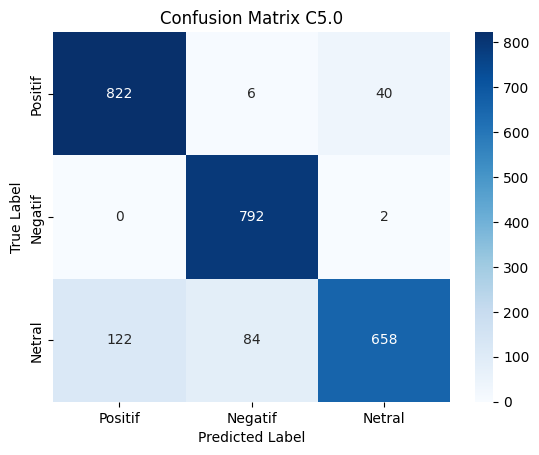

Confusion Matrix:
[[822   6  40]
 [  0 792   2]
 [122  84 658]]
waktu komputasi modelling =  68.9 secs   2.3 MByte


In [26]:
# Model training
time_start = time.perf_counter()
modelc50 = DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=42)

# Evaluasi dengan K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Menyimpan nilai akurasi, presisi, recall, dan f1-score untuk setiap fold
model_accuracy_scores = []
model_precision_scores = []
model_recall_scores = []
model_f1_scores = []

print('Evaluasi K-Fold Cross Validation:')
for temp_for_joblib in range(1,6):
    X_train_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_train_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])
    X_val_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_val_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])
    y_train_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_train_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])
    y_val_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_val_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])

    # Melatih model pada data latih fold
    modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/model_C50{temp_for_joblib}.joblib')


    # Prediksi pada data validasi fold
    y_val_pred = modelc50.predict(X_val_fold)

    # Hitung metrik evaluasi
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average='macro')
    recall = recall_score(y_val_fold, y_val_pred, average='macro')
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')

    model_accuracy_scores.append(accuracy)
    model_precision_scores.append(precision)
    model_recall_scores.append(recall)
    model_f1_scores.append(f1)

    print(f"K-Fold {temp_for_joblib}:")
    print("  Accuracy:  {:.2f}%".format(accuracy * 100))
    print("  Precision: {:.2f}%".format(precision * 100))
    print("  Recall:    {:.2f}%".format(recall * 100))
    print("  F1-Score:  {:.2f}%".format(f1 * 100))

print("\nRata-rata Evaluasi dari semua fold:")
print(f"Rata-rata Accuracy:  {np.mean(model_accuracy_scores)*100:.2f}%")
print(f"Rata-rata Precision: {np.mean(model_precision_scores)*100:.2f}%")
print(f"Rata-rata Recall:    {np.mean(model_recall_scores)*100:.2f}%")
print(f"Rata-rata F1-Score:  {np.mean(model_f1_scores)*100:.2f}%")
model_accuracy_scores.append(np.mean(model_accuracy_scores))
model_precision_scores.append(np.mean(model_precision_scores))
model_recall_scores.append(np.mean(model_recall_scores))
model_f1_scores.append(np.mean(model_f1_scores))


nilai_maksimum = max(model_accuracy_scores[:-1])
indeks_maksimum = model_accuracy_scores.index(nilai_maksimum)+1
modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/model_C50{indeks_maksimum}.joblib')

# Evaluasi model pada data testing
print("\nEvaluasi pada data Testing:")
model_y_test_pred = modelc50.predict(X_test)
accuracy1 = accuracy_score(y_test, model_y_test_pred)
model_accuracy_scores.append(accuracy1)
print("Accuracy:  {:.2f}%".format(accuracy1 * 100))
precision1 = precision_score(y_test, model_y_test_pred, average='macro')
model_precision_scores.append(precision1)
print("Precision: {:.2f}%".format(precision1 * 100))
recall1 = recall_score(y_test, model_y_test_pred, average='macro')
model_recall_scores.append(recall1)
print("Recall:    {:.2f}%".format(recall1 * 100))
f1score = f1_score(y_test, model_y_test_pred, average='macro')
model_f1_scores.append(f1score)
print("F1-Score:  {:.2f}%".format(f1score * 100))
print("Classification Report:")
print(classification_report(y_test, model_y_test_pred))


# Membuat confusion matrix
confusion = confusion_matrix(y_test, model_y_test_pred)
class_label = ["Positif", "Negatif", "Netral"]  # Sesuaikan ini dengan label dataset Anda
confusion_df = pd.DataFrame(confusion, index=class_label, columns=class_label)
buat_plot=sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix C5.0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix:")
print(confusion)

# Komputasi
modelling_time_elapsed = (time.perf_counter() - time_start)
modelling_memMb=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024.0/1024.0
print ("waktu komputasi modelling = %5.1f secs %5.1f MByte" % (modelling_time_elapsed,modelling_memMb))


In [27]:
print(X_train_fold)

           air    terjun     bagus  tiket     masuk     murah  ribu  orang  \
0     0.609224  0.749072  0.000000    0.0  0.000000  0.000000   0.0    0.0   
1     0.000000  0.000000  0.000000    0.0  0.000000  0.000000   0.0    0.0   
2     0.000000  0.000000  0.000000    0.0  0.000000  0.000000   0.0    0.0   
3     0.000000  0.000000  0.000000    0.0  0.000000  0.000000   0.0    0.0   
4     0.000000  0.000000  0.521812    0.0  0.000000  1.388493   0.0    0.0   
...        ...       ...       ...    ...       ...       ...   ...    ...   
8076  0.000000  0.000000  0.000000    0.0  0.000000  0.000000   0.0    0.0   
8077  0.000000  0.000000  0.000000    0.0  0.000000  0.000000   0.0    0.0   
8078  0.000000  0.000000  0.782719    0.0  0.000000  0.000000   0.0    0.0   
8079  0.000000  0.000000  0.000000    0.0  0.000000  0.000000   0.0    0.0   
8080  0.000000  0.000000  0.000000    0.0  0.151295  0.000000   0.0    0.0   

      jernih  langsung  ...  tema  pertama  mamtap  bosqu  pako

In [28]:
test = [3,1,4,5]

nilai_maksimum = max(test[:-1])

indeks_maksimum = test.index(nilai_maksimum)
indeks_maksimum

2

Text(0, 0.5, 'persentase (%)')

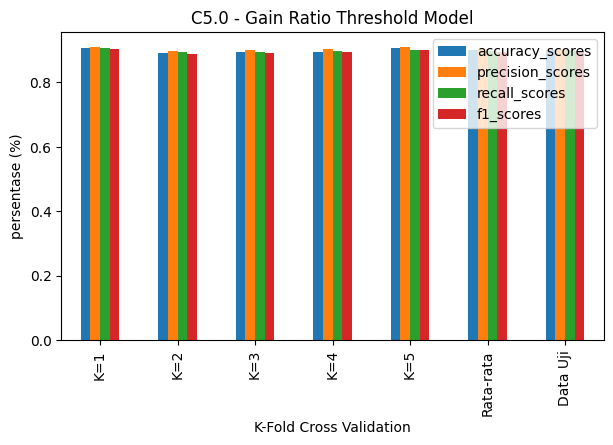

In [29]:
c = {
    "accuracy_scores":model_accuracy_scores,
    "precision_scores":model_precision_scores,
    "recall_scores":model_recall_scores,
    "f1_scores":model_f1_scores

}

plotdata = pd.DataFrame(c,
    index=["K=1",
    "K=2",
    "K=3",
    "K=4",
    "K=5",
    "Rata-rata",
    "Data Uji"])

plotdata.plot(kind="bar",figsize=(7, 4))

plt.title("C5.0 - Gain Ratio Threshold Model")

plt.xlabel("K-Fold Cross Validation")

plt.ylabel("persentase (%)")

In [30]:
model_accuracy_scores

[0.9079663532904503,
 0.8925742574257426,
 0.8945544554455446,
 0.8960396039603961,
 0.9064356435643565,
 0.899514062737298,
 0.89944576405384]

In [31]:
class_re=classification_report(y_test, model_y_test_pred)
print(class_re)

              precision    recall  f1-score   support

     Negatif       0.87      0.95      0.91       868
      Netral       0.90      1.00      0.95       794
     Positif       0.94      0.76      0.84       864

    accuracy                           0.90      2526
   macro avg       0.90      0.90      0.90      2526
weighted avg       0.90      0.90      0.90      2526



In [32]:
akurasinya_model=pd.DataFrame({"akurasi":model_accuracy_scores,"precision":model_precision_scores,"recall":model_recall_scores,"f1 score":model_f1_scores})
joblib.dump([akurasinya_model,model_y_test_pred,class_re,confusion_df,modelling_time_elapsed],"/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/model_C50_akurasi.joblib")

['/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/model_C50_akurasi.joblib']

In [33]:
akurasinya_model,prediksi_datatest_model,class_re,plotnya_model,waktu_komputasi=joblib.load("/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/model_C50_akurasi.joblib")
akurasinya_model

,akurasi,precision,recall,f1 score
0,0.907966,0.910411,0.906365,0.905062
1,0.892574,0.898408,0.894283,0.889319
2,0.894554,0.900805,0.895116,0.891006
3,0.896040,0.902375,0.898877,0.893626
4,0.906436,0.910273,0.900880,0.901226
5,0.899514,0.904454,0.899104,0.896048
6,0.899446,0.902907,0.902020,0.897941


In [34]:
import graphviz
# DOT data
dot_data = tree.export_graphviz(modelc50, out_file=None,
                                feature_names=modelc50.feature_names,
                                class_names=['Negatif','Netral','Positif'],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

Output hidden; open in https://colab.research.google.com to view.

In [35]:
temp=0
for i in X_test.index:
  print(temp)
  print("Data uji ",i)
  print("Ulasan",X_resampled.loc[i]["stemming"])
  print("Label",y_resampled.loc[i])
  print("prediksi",model_y_test_pred[temp])
  print()
  temp=temp+1

Output streaming akan dipotong hingga 5000 baris terakhir.
prediksi Negatif

1693
Data uji  1693
Ulasan ['tempat', 'keren', 'akses', 'jalan', 'baik', 'kelola', 'bagus', 'undang', 'wisatawan']
Label Positif
prediksi Netral

1694
Data uji  1694
Ulasan ['spot', 'foto', 'keren', 'untung', 'pas', 'suasana', 'panas', 'hasil', 'foto', 'bagus', 'akses', 'masuk', 'jaddih', 'jalan']
Label Positif
prediksi Negatif

1695
Data uji  1695
Ulasan ['alhamdulillaah', 'bukit', 'jaddih', 'bangkal', 'pulau', 'madura', 'tempat', 'potensial', 'wisata', 'kembang', 'wisata', 'tingkat']
Label Positif
prediksi Negatif

1696
Data uji  1696
Ulasan ['bukit', 'kapur', 'bentuk', 'tata', 'bentuk', 'kotak', 'julang', 'tangga', 'naik', 'ruang', 'gali', 'bentuk', 'kubang', 'isi', 'air', 'hujan', 'air']
Label Positif
prediksi Netral

1697
Data uji  1697
Ulasan ['daerah', 'bangkal', 'madura', 'akses', 'jalan', 'kesana', 'motor', 'mobil', 'tempat', 'bagus', 'bawa', 'payung', 'topi', 'sunblock', 'panas']
Label Positif
predik

In [36]:
import graphviz
# model_modelc50=model_modelc50
# DOT data
dot_data = tree.export_graphviz(modelc50, out_file=None,
                                feature_names=modelc50.feature_names,
                                class_names=['Negatif','Netral','Positif'],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

Output hidden; open in https://colab.research.google.com to view.

## Gain Ratio


In [37]:
# # Memeriksa apakah semua fitur numerik. Jika tidak, harus dikonversi.
# if not all([pd.api.types.is_numeric_dtype(X_train[col]) for col in X_train.columns]):
#     X_train = pd.get_dummies(X_train)
#     X_test = pd.get_dummies(X_test)

#     # Menyamakan kolom antara X_train dan X_test setelah One-Hot Encoding
#     X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# # Mengonversi label ke numerik jika belum dalam bentuk numerik
# label_encoder = LabelEncoder()
# y_train_encoded = label_encoder.fit_transform(y_train)
# y_test_encoded = label_encoder.transform(y_test)  # Juga mengonversi y_test

# # Fungsi untuk menghitung Gain Ratio
# def calculate_gain_ratio(X, y):
#     # Menghitung mutual information (serupa dengan informasi gain)
#     mutual_info = mutual_info_classif(X, y,random_state=42, discrete_features=False)
#     # Menghitung entropy dari label
#     entropy_y = -np.sum([p * np.log2(p) for p in np.bincount(y) / len(y)])
#     # Menghitung Gain Ratio
#     gain_ratio = mutual_info / entropy_y
#     return gain_ratio

# # Menghitung Gain Ratio untuk setiap fitur
# gain_ratios = calculate_gain_ratio(X_train, y_train_encoded)

In [38]:
pd_gain_ratios=pd.read_csv(f'/content/drive/MyDrive/Textmining/metode/DATA/PREPROCESSING/gain_ratios.csv')
pd_gain_ratios=pd_gain_ratios.drop(columns="Unnamed: 0")

In [39]:
gain_ratios=pd_gain_ratios.to_numpy()
# gaian_r=gaian_r[:,1:]
gain_ratios

array([[0.00734666],
       [0.00465416],
       [0.05097184],
       ...,
       [0.        ],
       [0.00077912],
       [0.        ]])

In [40]:
gain_ratios=gain_ratios.reshape(-1)
gain_ratios

array([0.00734666, 0.00465416, 0.05097184, ..., 0.        , 0.00077912,
       0.        ])

In [41]:
print(len(gain_ratios))
print(len(X_train.columns))
for i in range(len(gain_ratios)):
  print(X_train.columns[i],":",gain_ratios[i])
# for i in range(gain_ratios)

4216
4216
air : 0.0073466576871439
terjun : 0.0046541612183134
bagus : 0.0509718371617838
tiket : 0.0099200814120061
masuk : 0.029605895205868
murah : 0.0068310737061183
ribu : 0.0120331126817088
orang : 0.0148980330557679
jernih : 0.0
langsung : 0.0097921205189625
berangan : 0.0038005561715647
laut : 0.0065735247267149
tempat : 0.010464867689593
atas : 0.0
rest : 0.0
area : 0.0025109618313274
parkir : 0.009651038120868
mantap : 0.0120978213354483
pandang : 0.0119739938792535
indah : 0.0244911594493256
adem : 0.009361090463271
suasanyanya : 0.0001671331030544
pinggir : 0.0014142541286123
cuman : 0.0046988744806655
terjunya : 0.0048686988280104
musim : 0.0078374055841253
hujan : 0.0078163641751917
wisata : 0.0168415087612105
keren : 0.0131600332608135
recomended : 0.0020555161963254
banget : 0.0094537538681085
kunjung : 0.0095695041949583
kuliner : 0.0003189855352644
es : 0.0010253429590338
degan : 0.0028149662653031
move : 0.0027694818385732
on : 0.0
mantan : 0.0
restoran : 0.0
harga :

### Mean


In [42]:
# Mengonversi label ke numerik jika belum dalam bentuk numerik
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)  # Juga mengonversi y_test

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_label.py:134: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


Total fitur yang telah diseleksi:  1488
Evaluasi K-Fold Cross Validation:
K-Fold 1:
  Accuracy:  87.48%
  Precision: 88.30%
  Recall:    87.26%
  F1-Score:  86.98%
K-Fold 2:
  Accuracy:  87.08%
  Precision: 88.18%
  Recall:    87.27%
  F1-Score:  86.63%
K-Fold 3:
  Accuracy:  87.33%
  Precision: 88.24%
  Recall:    87.40%
  F1-Score:  86.85%
K-Fold 4:
  Accuracy:  87.28%
  Precision: 88.23%
  Recall:    87.61%
  F1-Score:  86.91%
K-Fold 5:
  Accuracy:  88.86%
  Precision: 89.51%
  Recall:    88.22%
  F1-Score:  88.23%

Rata-rata Evaluasi dari semua fold:
Rata-rata Accuracy:  87.61%
Rata-rata Precision: 88.49%
Rata-rata Recall:    87.55%
Rata-rata F1-Score:  87.12%

Evaluasi pada data Testing:
Accuracy:  87.17%
Precision: 87.74%
Recall:    87.49%
F1-Score:  86.86%
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.87      0.93      0.89       868
      Netral       0.84      0.99      0.91       794
     Positif       0.93      0.71      0

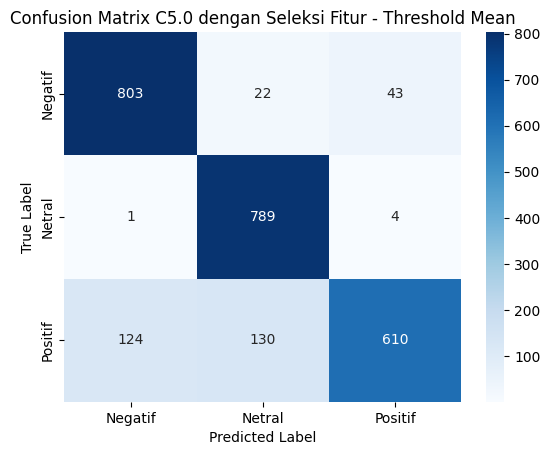

Confusion Matrix:
[[803  22  43]
 [  1 789   4]
 [124 130 610]]
Waktu komputasi: 60.12 detik
Penggunaan memori: 2.40 MB


In [43]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import resource
import warnings

# Mengabaikan semua peringatan
warnings.filterwarnings('ignore')

# Mulai pengukuran waktu komputasi
time_start = time.perf_counter()


# Menentukan threshold sebagai rata-rata Gain Ratio
threshold = gain_ratios.mean()

# Memilih fitur yang Gain Ratio-nya di atas threshold
selected_features = X_train.columns[gain_ratios > threshold]
print('Total fitur yang telah diseleksi: ', len(selected_features))

# Menggunakan fitur yang dipilih untuk pelatihan model
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Model training
mean_modelc50 = DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=42)

# Evaluasi dengan K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Menyimpan nilai akurasi, presisi, recall, dan f1-score untuk setiap fold
mean_accuracy_scores = []
mean_precision_scores = []
mean_recall_scores = []
mean_f1_scores = []

temp_for_joblib=1
print('Evaluasi K-Fold Cross Validation:')
for temp_for_joblib in range(1,6):
    X_train_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_train_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])[selected_features]
    X_val_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_val_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])[selected_features]
    y_train_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_train_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])
    y_val_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_val_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])
    temp=0

    # # Melatih model pada data latih fold
    mean_modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/mean_C50_{temp_for_joblib}.joblib')

    # Melatih model pada data latih fold
    # mean_modelc50.fit(X_train_fold, y_train_fold)
    # mean_modelc50.feature_names=X_train_fold.columns
    for i in mean_modelc50.feature_names:
      if i not in X_val_fold.columns:
        X_val_fold.insert(temp, i, 0)
      temp+=1
    ft=[]
    for i in mean_modelc50.feature_names:
      ft.append(i)
    X_val_fold=X_val_fold[ft]

    # Prediksi pada data validasi fold
    y_val_pred = mean_modelc50.predict(X_val_fold)
    y_val_pred=label_encoder.inverse_transform(y_val_pred)

    # Hitung metrik evaluasi
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average='macro')
    recall = recall_score(y_val_fold, y_val_pred, average='macro')
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    # mean_modelc50.accuracy=accuracy
    # mean_modelc50.precision=precision
    # mean_modelc50.recall=recall
    # mean_modelc50.f1=f1


    # joblib.dump(mean_modelc50,f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/mean_C50_{temp_for_joblib}.joblib')
    # Simpan metrik evaluasi
    mean_accuracy_scores.append(accuracy)
    mean_precision_scores.append(precision)
    mean_recall_scores.append(recall)
    mean_f1_scores.append(f1)

    print(f"K-Fold {temp_for_joblib}:")
    print(f"  Accuracy:  {accuracy * 100:.2f}%")
    print(f"  Precision: {precision * 100:.2f}%")
    print(f"  Recall:    {recall * 100:.2f}%")
    print(f"  F1-Score:  {f1 * 100:.2f}%")
    temp_for_joblib+=1

# Menampilkan rata-rata evaluasi dari semua fold
print("\nRata-rata Evaluasi dari semua fold:")
print(f"Rata-rata Accuracy:  {np.mean(mean_accuracy_scores) * 100:.2f}%")
print(f"Rata-rata Precision: {np.mean(mean_precision_scores) * 100:.2f}%")
print(f"Rata-rata Recall:    {np.mean(mean_recall_scores) * 100:.2f}%")
print(f"Rata-rata F1-Score:  {np.mean(mean_f1_scores) * 100:.2f}%")
mean_accuracy_scores.append(np.mean(mean_accuracy_scores))
mean_precision_scores.append(np.mean(mean_precision_scores))
mean_recall_scores.append(np.mean(mean_recall_scores))
mean_f1_scores.append(np.mean(mean_f1_scores))

# Evaluasi model pada data testing

nilai_maksimum = max(mean_accuracy_scores[:-1])
indeks_maksimum = mean_accuracy_scores.index(nilai_maksimum)+1

mean_modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/mean_C50_{indeks_maksimum}.joblib')

print("\nEvaluasi pada data Testing:")
temp=0
for i in mean_modelc50.feature_names:
  if i not in X_test_selected.columns:
    X_test_selected.insert(temp, i, 0)
  temp+=1
ft=[]
for i in mean_modelc50.feature_names:
  ft.append(i)
X_test_selected=X_test_selected[ft]
mean_y_test_pred = mean_modelc50.predict(X_test_selected)
mean_y_test_encoded = y_test_encoded
accuracy_test = accuracy_score(mean_y_test_encoded, mean_y_test_pred)
precision_test = precision_score(mean_y_test_encoded, mean_y_test_pred, average='macro')
recall_test = recall_score(mean_y_test_encoded, mean_y_test_pred, average='macro')
f1_test = f1_score(mean_y_test_encoded, mean_y_test_pred, average='macro')
mean_accuracy_scores.append(accuracy_test)
mean_precision_scores.append(precision_test)
mean_recall_scores.append(recall_test)
mean_f1_scores.append(f1_test)
print(f"Accuracy:  {accuracy_test * 100:.2f}%")
print(f"Precision: {precision_test * 100:.2f}%")
print(f"Recall:    {recall_test * 100:.2f}%")
print(f"F1-Score:  {f1_test * 100:.2f}%")

# Menampilkan Classification Report
print("Classification Report:")
mean_y_test_encoded=label_encoder.inverse_transform(mean_y_test_encoded)
mean_y_test_pred=label_encoder.inverse_transform(mean_y_test_pred)
print(classification_report(mean_y_test_encoded, mean_y_test_pred))

# Membuat confusion matrix
confusion = confusion_matrix(mean_y_test_encoded, mean_y_test_pred)
class_labels = label_encoder.classes_  # Gunakan label yang sesuai dengan dataset
confusion_df = pd.DataFrame(confusion, index=class_labels, columns=class_labels)
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix C5.0 dengan Seleksi Fitur - Threshold Mean")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix:")
print(confusion)

# Pengukuran waktu komputasi dan penggunaan memori
time_elapsed = (time.perf_counter() - time_start)
mem_usage_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0 / 1024.0
print(f"Waktu komputasi: {time_elapsed:.2f} detik")
print(f"Penggunaan memori: {mem_usage_mb:.2f} MB")



In [44]:
temp=0
for i in modelc50.feature_names:
  if i not in X_test_selected.columns:
    X_test_selected.insert(temp, i, 0)
  temp+=1
ft=[]
for i in modelc50.feature_names:
  ft.append(i)
X_test_selected=X_test_selected[ft]

In [45]:
threshold

0.0018618187777569158

In [46]:
fitur_yang_dibuang = X_train.columns[gain_ratios < threshold]

In [47]:
X_train[fitur_yang_dibuang]

,jernih,atas,rest,suasanyanya,pinggir,kuliner,es,on,mantan,restoran,...,ticket,okok,pipis,tema,mamtap,bosqu,pakong,serru,jenius,siiiip
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10099,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0, 0.5, 'persentase (%)')

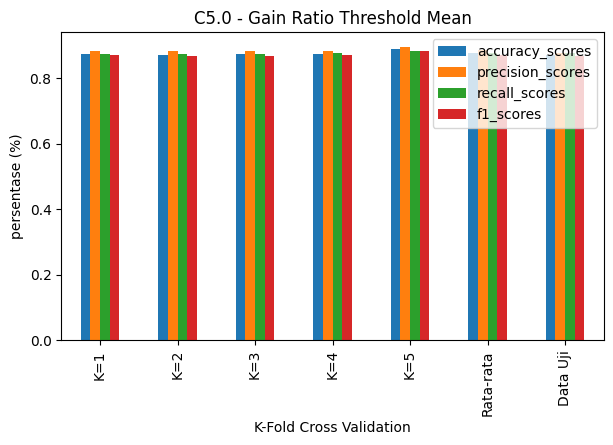

In [48]:
c = {
    "accuracy_scores":mean_accuracy_scores,
    "precision_scores":mean_precision_scores,
    "recall_scores":mean_recall_scores,
    "f1_scores":mean_f1_scores

}

plotdata = pd.DataFrame(c,
    index=["K=1",
    "K=2",
    "K=3",
    "K=4",
    "K=5",
    "Rata-rata",
    "Data Uji"])

plotdata.plot(kind="bar",figsize=(7, 4))

plt.title("C5.0 - Gain Ratio Threshold Mean")

plt.xlabel("K-Fold Cross Validation")

plt.ylabel("persentase (%)")

In [49]:
temp=0
for i in X_test.index:
  print(temp)
  print("Data uji ",i)
  print("Ulasan",X_resampled.loc[i]["stemming"])
  print("Label",y_resampled.loc[i])
  print("prediksi",mean_y_test_pred[temp])
  print()
  temp=temp+1

Output streaming akan dipotong hingga 5000 baris terakhir.
prediksi Negatif

1693
Data uji  1693
Ulasan ['tempat', 'keren', 'akses', 'jalan', 'baik', 'kelola', 'bagus', 'undang', 'wisatawan']
Label Positif
prediksi Netral

1694
Data uji  1694
Ulasan ['spot', 'foto', 'keren', 'untung', 'pas', 'suasana', 'panas', 'hasil', 'foto', 'bagus', 'akses', 'masuk', 'jaddih', 'jalan']
Label Positif
prediksi Negatif

1695
Data uji  1695
Ulasan ['alhamdulillaah', 'bukit', 'jaddih', 'bangkal', 'pulau', 'madura', 'tempat', 'potensial', 'wisata', 'kembang', 'wisata', 'tingkat']
Label Positif
prediksi Negatif

1696
Data uji  1696
Ulasan ['bukit', 'kapur', 'bentuk', 'tata', 'bentuk', 'kotak', 'julang', 'tangga', 'naik', 'ruang', 'gali', 'bentuk', 'kubang', 'isi', 'air', 'hujan', 'air']
Label Positif
prediksi Netral

1697
Data uji  1697
Ulasan ['daerah', 'bangkal', 'madura', 'akses', 'jalan', 'kesana', 'motor', 'mobil', 'tempat', 'bagus', 'bawa', 'payung', 'topi', 'sunblock', 'panas']
Label Positif
predik

In [50]:
X_train_selected

,air,terjun,bagus,tiket,masuk,murah,ribu,orang,langsung,berangan,...,sajadah,perempuan,amanah,rami,keluargs,mtr,tiru,pertama,vroh,samale
0,0.609224,0.749072,0.000000,0.0,0.000000,0.0,0.0,0.0,0.999214,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10097,0.000000,0.000000,0.782719,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10098,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10099,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
y_test_encoded

array([1, 0, 2, ..., 0, 2, 1])

In [52]:
class_re_mean=classification_report(y_test, mean_y_test_pred)
print(class_re_mean)

              precision    recall  f1-score   support

     Negatif       0.87      0.93      0.89       868
      Netral       0.84      0.99      0.91       794
     Positif       0.93      0.71      0.80       864

    accuracy                           0.87      2526
   macro avg       0.88      0.87      0.87      2526
weighted avg       0.88      0.87      0.87      2526



In [53]:
akurasinya_mean=pd.DataFrame({"akurasi":mean_accuracy_scores,"precision":mean_precision_scores,"recall":mean_recall_scores,"f1 score":mean_f1_scores})
joblib.dump([akurasinya_mean,mean_y_test_pred,class_re_mean,confusion_df,time_elapsed],"/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/mean_C50_akurasi.joblib")

['/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/mean_C50_akurasi.joblib']

In [54]:
akurasinya_mean,prediksi_datatest_mean,class_re,plotnya_mean,waktu_komputasi=joblib.load("/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/mean_C50_akurasi.joblib")
akurasinya_mean

,akurasi,precision,recall,f1 score
0,0.874814,0.882974,0.872625,0.869783
1,0.870792,0.881772,0.872701,0.866265
2,0.873267,0.882365,0.874007,0.868520
3,0.872772,0.882323,0.876110,0.869055
4,0.888614,0.895077,0.882156,0.882280
5,0.876052,0.884902,0.875520,0.871181
6,0.871734,0.877411,0.874945,0.868608


In [55]:
import graphviz
# mean_modelc50=modelc50
# DOT data
dot_data = tree.export_graphviz(mean_modelc50, out_file=None,
                                feature_names=mean_modelc50.feature_names,
                                class_names=['Negatif','Netral','Positif'],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

Output hidden; open in https://colab.research.google.com to view.

### Median

Total fitur yang telah diseleksi:  2108
Evaluasi K-Fold Cross Validation:
K-Fold 1:
  Accuracy:  88.22%
  Precision: 88.80%
  Recall:    88.01%
  F1-Score:  87.74%
K-Fold 2:
  Accuracy:  87.87%
  Precision: 88.76%
  Recall:    88.05%
  F1-Score:  87.47%
K-Fold 3:
  Accuracy:  88.27%
  Precision: 89.03%
  Recall:    88.33%
  F1-Score:  87.85%
K-Fold 4:
  Accuracy:  88.61%
  Precision: 89.36%
  Recall:    88.92%
  F1-Score:  88.31%
K-Fold 5:
  Accuracy:  89.75%
  Precision: 90.25%
  Recall:    89.14%
  F1-Score:  89.17%

Rata-rata Evaluasi dari semua fold:
Rata-rata Accuracy:  88.55%
Rata-rata Precision: 89.24%
Rata-rata Recall:    88.49%
Rata-rata F1-Score:  88.11%

Evaluasi pada data Testing:
Accuracy:  87.81%
Precision: 88.47%
Recall:    88.11%
F1-Score:  87.46%
Classification Report:
              precision    recall  f1-score   support

     Negatif       0.86      0.95      0.90       868
      Netral       0.86      0.99      0.92       794
     Positif       0.94      0.70      0

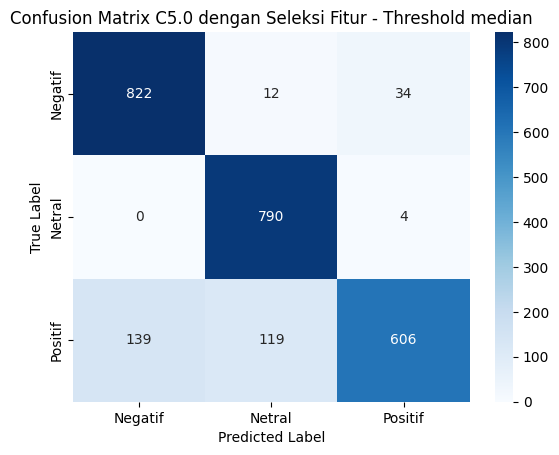

Confusion Matrix:
[[822  12  34]
 [  0 790   4]
 [139 119 606]]
Waktu komputasi: 40.86 detik
Penggunaan memori: 2.64 MB


In [56]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import resource
import warnings

# Mengabaikan semua peringatan
warnings.filterwarnings('ignore')

# Mulai pengukuran waktu komputasi
time_start = time.perf_counter()


# Menentukan threshold sebagai rata-rata Gain Ratio
threshold = np.median(gain_ratios)

# Memilih fitur yang Gain Ratio-nya di atas threshold
selected_features = X_train.columns[gain_ratios > threshold]
print('Total fitur yang telah diseleksi: ', len(selected_features))

# Menggunakan fitur yang dipilih untuk pelatihan model
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Model training
median_modelc50 = DecisionTreeClassifier(criterion="entropy", max_depth=None, random_state=42)

# Evaluasi dengan K-Fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Menyimpan nilai akurasi, presisi, recall, dan f1-score untuk setiap fold
median_accuracy_scores = []
median_precision_scores = []
median_recall_scores = []
median_f1_scores = []

temp_for_joblib=1
print('Evaluasi K-Fold Cross Validation:')
for temp_for_joblib in range(1,6):
    X_train_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_train_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])[selected_features]
    X_val_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/X_val_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])[selected_features]
    y_train_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_train_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])
    y_val_fold=pd.read_csv(f"/content/drive/MyDrive/Textmining/metode/DATA/SPLIT/y_val_fold{temp_for_joblib}.csv").drop(columns=["Unnamed: 0"])
    temp=0

    # # Melatih model pada data latih fold
    median_modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/median_c50{temp_for_joblib}.joblib')

    # Melatih model pada data latih fold
    # median_modelc50.fit(X_train_fold, y_train_fold)
    # median_modelc50.feature_names=X_train_fold.columns
    for i in median_modelc50.feature_names:
      if i not in X_val_fold.columns:
        X_val_fold.insert(temp, i, 0)
      temp+=1
    ft=[]
    for i in median_modelc50.feature_names:
      ft.append(i)
    X_val_fold=X_val_fold[ft]

    # Prediksi pada data validasi fold
    y_val_pred = median_modelc50.predict(X_val_fold)
    y_val_pred=label_encoder.inverse_transform(y_val_pred)

    # Hitung metrik evaluasi
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    precision = precision_score(y_val_fold, y_val_pred, average='macro')
    recall = recall_score(y_val_fold, y_val_pred, average='macro')
    f1 = f1_score(y_val_fold, y_val_pred, average='macro')
    # median_modelc50.accuracy=accuracy
    # median_modelc50.precision=precision
    # median_modelc50.recall=recall
    # median_modelc50.f1=f1


    # joblib.dump(median_modelc50,f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/median_c50{temp_for_joblib}.joblib')
    # Simpan metrik evaluasi
    median_accuracy_scores.append(accuracy)
    median_precision_scores.append(precision)
    median_recall_scores.append(recall)
    median_f1_scores.append(f1)

    print(f"K-Fold {temp_for_joblib}:")
    print(f"  Accuracy:  {accuracy * 100:.2f}%")
    print(f"  Precision: {precision * 100:.2f}%")
    print(f"  Recall:    {recall * 100:.2f}%")
    print(f"  F1-Score:  {f1 * 100:.2f}%")
    # temp_for_joblib+=1

# Menampilkan rata-rata evaluasi dari semua fold
print("\nRata-rata Evaluasi dari semua fold:")
print(f"Rata-rata Accuracy:  {np.mean(median_accuracy_scores) * 100:.2f}%")
print(f"Rata-rata Precision: {np.mean(median_precision_scores) * 100:.2f}%")
print(f"Rata-rata Recall:    {np.mean(median_recall_scores) * 100:.2f}%")
print(f"Rata-rata F1-Score:  {np.mean(median_f1_scores) * 100:.2f}%")
median_accuracy_scores.append(np.mean(median_accuracy_scores))
median_precision_scores.append(np.mean(median_precision_scores))
median_recall_scores.append(np.mean(median_recall_scores))
median_f1_scores.append(np.mean(median_f1_scores))

# Evaluasi model pada data testing

nilai_maksimum = max(model_accuracy_scores[:-1])
indeks_maksimum = model_accuracy_scores.index(nilai_maksimum)+1

median_modelc50=joblib.load(f'/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/median_c50{indeks_maksimum}.joblib')

print("\nEvaluasi pada data Testing:")
temp=0
for i in median_modelc50.feature_names:
  if i not in X_test_selected.columns:
    X_test_selected.insert(temp, i, 0)
  temp+=1
ft=[]
for i in median_modelc50.feature_names:
  ft.append(i)
X_test_selected=X_test_selected[ft]
median_y_test_pred = median_modelc50.predict(X_test_selected)
median_y_test_encoded=y_test_encoded
accuracy_test = accuracy_score(median_y_test_encoded, median_y_test_pred)
precision_test = precision_score(median_y_test_encoded, median_y_test_pred, average='macro')
recall_test = recall_score(median_y_test_encoded, median_y_test_pred, average='macro')
f1_test = f1_score(median_y_test_encoded, median_y_test_pred, average='macro')
median_accuracy_scores.append(accuracy_test)
median_precision_scores.append(precision_test)
median_recall_scores.append(recall_test)
median_f1_scores.append(f1_test)
print(f"Accuracy:  {accuracy_test * 100:.2f}%")
print(f"Precision: {precision_test * 100:.2f}%")
print(f"Recall:    {recall_test * 100:.2f}%")
print(f"F1-Score:  {f1_test * 100:.2f}%")

# Menampilkan Classification Report
print("Classification Report:")
median_y_test_encoded=label_encoder.inverse_transform(median_y_test_encoded)
median_y_test_pred=label_encoder.inverse_transform(median_y_test_pred)
print(classification_report(median_y_test_encoded, median_y_test_pred))

# Membuat confusion matrix
confusion = confusion_matrix(median_y_test_encoded, median_y_test_pred)
class_labels = label_encoder.classes_  # Gunakan label yang sesuai dengan dataset
confusion_df = pd.DataFrame(confusion, index=class_labels, columns=class_labels)
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix C5.0 dengan Seleksi Fitur - Threshold median")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("Confusion Matrix:")
print(confusion)

# Pengukuran waktu komputasi dan penggunaan memori
time_elapsed = (time.perf_counter() - time_start)
mem_usage_mb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0 / 1024.0
print(f"Waktu komputasi: {time_elapsed:.2f} detik")
print(f"Penggunaan memori: {mem_usage_mb:.2f} MB")




In [57]:
threshold

0.00050010740475015

In [58]:
fitur_yang_dibuang_oleh_median = X_train.columns[gain_ratios < threshold]

In [59]:
X_train[fitur_yang_dibuang_oleh_median]

,jernih,atas,rest,suasanyanya,kuliner,on,mantan,restoran,poin,dusim,...,gabanyak,sakura,okok,pipis,tema,mamtap,bosqu,pakong,serru,siiiip
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10099,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Text(0, 0.5, 'persentase (%)')

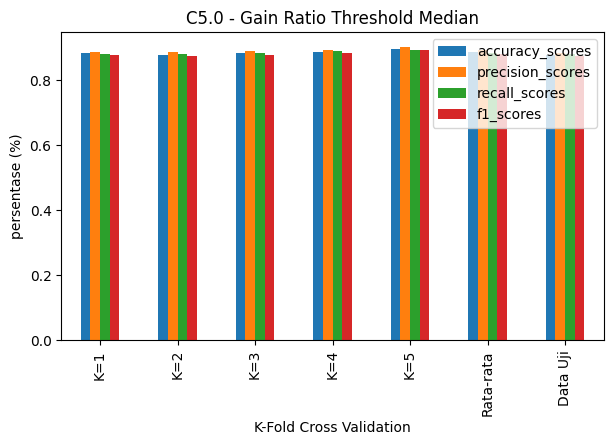

In [60]:
c = {
    "accuracy_scores":median_accuracy_scores,
    "precision_scores":median_precision_scores,
    "recall_scores":median_recall_scores,
    "f1_scores":median_f1_scores

}

plotdata = pd.DataFrame(c,
    index=["K=1",
    "K=2",
    "K=3",
    "K=4",
    "K=5",
    "Rata-rata",
    "Data Uji"])

plotdata.plot(kind="bar",figsize=(7, 4))

plt.title("C5.0 - Gain Ratio Threshold Median")

plt.xlabel("K-Fold Cross Validation")

plt.ylabel("persentase (%)")

In [61]:
class_re_median=classification_report(y_test, median_y_test_pred)
print(class_re_median)

              precision    recall  f1-score   support

     Negatif       0.86      0.95      0.90       868
      Netral       0.86      0.99      0.92       794
     Positif       0.94      0.70      0.80       864

    accuracy                           0.88      2526
   macro avg       0.88      0.88      0.87      2526
weighted avg       0.89      0.88      0.87      2526



In [62]:
akurasinya_median=pd.DataFrame({"akurasi":median_accuracy_scores,"precision":median_precision_scores,"recall":median_recall_scores,"f1 score":median_f1_scores})
joblib.dump([akurasinya_median,median_y_test_pred,class_re_median,confusion_df,time_elapsed],"/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/median_C50_akurasi.joblib")

['/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/median_C50_akurasi.joblib']

In [63]:
akurasinya_median,prediksi_datatest_median,class_re,plotnya_median,waktu_komputasi=joblib.load("/content/drive/MyDrive/Textmining/metode/DATA/MODEL/ROS/median_C50_akurasi.joblib")
akurasinya_median

,akurasi,precision,recall,f1 score
0,0.882237,0.888013,0.880134,0.877369
1,0.878713,0.887622,0.880479,0.874719
2,0.882673,0.890293,0.883330,0.878490
3,0.886139,0.893585,0.889213,0.883122
4,0.897525,0.902514,0.891427,0.891664
5,0.885457,0.892405,0.884917,0.881073
6,0.878068,0.884705,0.881119,0.874616


In [64]:
temp=0
for i in X_test.index:
  print(temp)
  print("Data uji ",i)
  print("Ulasan",X_resampled.loc[i]["stemming"])
  print("Label",y_resampled.loc[i])
  print("prediksi",median_y_test_pred[temp])
  print()
  temp=temp+1

Output streaming akan dipotong hingga 5000 baris terakhir.
prediksi Negatif

1693
Data uji  1693
Ulasan ['tempat', 'keren', 'akses', 'jalan', 'baik', 'kelola', 'bagus', 'undang', 'wisatawan']
Label Positif
prediksi Netral

1694
Data uji  1694
Ulasan ['spot', 'foto', 'keren', 'untung', 'pas', 'suasana', 'panas', 'hasil', 'foto', 'bagus', 'akses', 'masuk', 'jaddih', 'jalan']
Label Positif
prediksi Negatif

1695
Data uji  1695
Ulasan ['alhamdulillaah', 'bukit', 'jaddih', 'bangkal', 'pulau', 'madura', 'tempat', 'potensial', 'wisata', 'kembang', 'wisata', 'tingkat']
Label Positif
prediksi Negatif

1696
Data uji  1696
Ulasan ['bukit', 'kapur', 'bentuk', 'tata', 'bentuk', 'kotak', 'julang', 'tangga', 'naik', 'ruang', 'gali', 'bentuk', 'kubang', 'isi', 'air', 'hujan', 'air']
Label Positif
prediksi Netral

1697
Data uji  1697
Ulasan ['daerah', 'bangkal', 'madura', 'akses', 'jalan', 'kesana', 'motor', 'mobil', 'tempat', 'bagus', 'bawa', 'payung', 'topi', 'sunblock', 'panas']
Label Positif
predik

In [65]:
import graphviz
# DOT data
dot_data = tree.export_graphviz(median_modelc50, out_file=None,
                                feature_names=median_modelc50.feature_names,
                                class_names=['Negatif','Netral','Positif'],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

Output hidden; open in https://colab.research.google.com to view.